<a href="https://colab.research.google.com/github/praffuln/agentic-ai/blob/master/checkpointers/sqlite3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install All Requierd Liberary for Program

#### langgraph-checkpoint-sqlite is library for sqlite external memory.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph-checkpoint-sqlite langchain_core langgraph langchain_openai

In [ ]:
%%capture --no-stderr;
%pip install -U langchain_community tiktoken langchainhub scikit-learn langchain langgraph tavily-python  nomic[local] langchain-nomic google-generativeai langchain_google_genai

## Setup SQLite

In [ ]:
import sqlite3
# In memory
conn = sqlite3.connect(":memory:", check_same_thread = False)

In [62]:
# pull file if it doesn't exist and connect to local db
!mkdir -p state_db && [ ! -f state_db/example.db ] && wget -P state_db https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db

## https://fastupload.io/3a8538937a14136a
## !mkdir -p state_db && [ ! -f state_db/example.db ] && wget -P state_db https://storage4.fastupload.io/3a8538937a14136a/example.db


db_path = "state_db/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

--2025-05-01 11:21:09--  https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db [following]
--2025-05-01 11:21:10--  https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 110592 (108K) [application/octet-stream]
Saving to: ‘state_db/example.db’

example.db          100%[===================>] 108.00K  --.-KB/s    in 0.03s   

2025-05-01 11:21:10 (3.91 MB/s) - ‘s

In [63]:
# Here is our checkpointer
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

## Setup Keys

In [64]:
from google.colab import userdata


In [54]:
# Assigning value to variable
GEMINI_API_KEY=userdata.get('GEMINI_API_KEY')
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
LANGCHAIN_API_KEY = userdata.get('LANGCHAIN_API_KEY')



In [55]:
import os
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS

os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY
os.environ['TAVILY_API_KEY'] = GEMINI_API_KEY

In [56]:
# LLM with function call
model = ChatGoogleGenerativeAI(model="gemini-1.5-flash", temperature=0.3) # Try using gemini-pro-vision
# Create embeddings using a Google Generative AI model
embedding = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

model.invoke('When is diwali in 2025?')

AIMessage(content='Diwali in 2025 will be celebrated on **November 12th**.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-951b6050-30fe-4cd5-a540-2a3fdb0a003b-0', usage_metadata={'input_tokens': 11, 'output_tokens': 20, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})

In [65]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

from langgraph.graph import END
from langgraph.graph import MessagesState


class State(MessagesState):
    summary: str


# Define the logic to call the model
def device_summary(state: State):

      # Add summary to system message
      system_message = f"Summary of questions passed with state, feel free to check wikipedia :"

      # Append summary to any newer messages
      messages = [SystemMessage(content=system_message)] + state["messages"]

      response = model.invoke(messages)
      return {"messages": response}





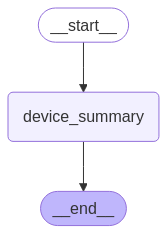

In [66]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("device_summary", device_summary)

# Set the entrypoint as conversation
workflow.add_edge(START, "device_summary")

# Compile
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [68]:
# Create a thread
config = {"configurable": {"thread_id": "sesa679075"}}

# Start conversation
input_message = HumanMessage(content="hi! my name is Bunty. I'm from schneider sales !")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-2:]:
    m.pretty_print()

input_message = HumanMessage(content="from which company I am ?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-2:]:
    m.pretty_print()

input_message = HumanMessage(content="i like to search on se.com about red switch")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-2:]:
    m.pretty_print()

================================ Human Message =================================

hi! my name is Bunty. I'm from schneider sales !
================================== Ai Message ==================================

Hi Bunty! Nice to meet you again.  Is there anything I can help you with today?
================================ Human Message =================================

from which company I am ?
================================== Ai Message ==================================

You've told me you're from Schneider Electric Sales.
================================ Human Message =================================

i like to search on se.com about red switch
================================== Ai Message ==================================

Okay, Bunty.  To find information about red switches on se.com (Schneider Electric's website), I recommend going directly to their website at www.se.com and using their search function.  You might have better luck with a more specific search term than just

## Print the graph state

In [69]:
config = {"configurable": {"thread_id": "sesa679075"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="hi! my name is Bunty. I'm from schneider sales !", additional_kwargs={}, response_metadata={}, id='4f583d25-4ed2-4004-83b5-f327543ed791'), AIMessage(content="Hello Bunty!  It's nice to meet you.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-a4007788-a4db-42a8-bff9-960f9e559340-0', usage_metadata={'input_tokens': 29, 'output_tokens': 14, 'total_tokens': 43, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='from which company I am ?', additional_kwargs={}, response_metadata={}, id='7cd9e3f2-1287-42b1-b0d1-d51fd0363092'), AIMessage(content='You said you are from Schneider Electric Sales.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-5bdfa661-2812-4bfb-a56f-8f49fb882fcb-0', usage_metadata={'i

## To Test the Persistant Graph State Restart the Session or Notebook or System

In [70]:
# Create a thread
config = {"configurable": {"thread_id": "sesa679075"}}

# Start conversation
input_message = HumanMessage(content="Who is Bunty ? What does he do ?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()


================================== Ai Message ==================================

Based on our conversation, Bunty is a person who works in sales for Schneider Electric.  Beyond that, I don't know anything else about him.


In [71]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="hi! I'm Lance", additional_kwargs={}, response_metadata={}, id='086e80ce-8bd0-4dee-b13c-f47160d6755f'), AIMessage(content="Hello Lance! You've already introduced yourself, but it's nice to greet you again. Is there something specific you'd like to talk about? Perhaps you'd like to continue our conversation about the 49ers, or is there another topic you're interested in discussing?", additional_kwargs={}, response_metadata={'id': 'msg_01AkDF6AH7LMp2YDDD9jQkEC', 'model': 'claude-3-5-sonnet-20240620', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'input_tokens': 197, 'output_tokens': 58}}, id='run-7f8af5e1-5248-4ccd-ab46-87580422f0d6-0', usage_metadata={'input_tokens': 197, 'output_tokens': 58, 'total_tokens': 255}), HumanMessage(content="what's my name?", additional_kwargs={}, response_metadata={}, id='e33f42ee-cdb0-45ec-b100-54dcd4c82e71'), AIMessage(content="Your name is Lance. You've introduced yourself twice durin